# Convolutional Neural Networks for Bird Species Classification

This project applies convolutional neural networks (CNNs) to sound data containing the calls of various birds in order to identify their species. Two separate approaches were taken when applying these machine learning models:

1) **Binary classification**: testing multiple CNN models in identifying between one of two bird species 
2) **Multi-class classification**: testing multiple CNN models in species identification for all 12 species in the dataset

The dataset in question contained bird call sound data from 12 different species, which was originally gathered by the Cornell Lab of Ornithology's Center for Conservation Bioacoustics. The Center's data was compiled and made available by Xeno-Canto, an online archive for various animal sounds, via Kaggle. While initially containing roughly 36 GB of data for a variety of bird species, this data was preprocessed to only contain data from 12 species, before selecting for 3 second clips of high quality sound data that were all converted into spectrogram images. These images would provide the basis on training and test data that were used to evaluate the convolutional neural network models developed here.

Following the development of both the binary and multi-class classifiers, the final multi-class classification model was then tested on three, previously unseen bird call sound clips. The model generated a predicted species for each clip, and was evaluated for the probabilities associated with each prediction.

The 12 bird species of interest and their corresponding six-letter codes are as folows:

1) American Crow (amecro)
2) American Robin (amerob)
3) Bewick's Wren (bewwre)
4) Black-capped Chickadee (bkcchi)
5) Dark-eyed Junco (daejun)
6) House Finch (houfin)
7) House Sparrow (houspa)
8) Northern Flicker (norfli)
9) Red-winged Blackbird (rewbla)
10) Song Sparrow (sonspa)
11) Spotted Towhee (spotow)
12) White-crowned Sparrow (whcspa)

Dataset (unprocessed):
Rao, R. (n.d.). Xeno-Canto bird recordings extended (A–M) [Data set]. Kaggle. https://www.kaggle.com/datasets/rohanrao/xeno-canto-bird-recordings-extended-a-m

## Import necessary libraries

In [1]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import image

import os
import librosa
import librosa.display

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.preprocessing import LabelBinarizer, StandardScaler
from sklearn.metrics import mean_absolute_error, confusion_matrix

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.preprocessing.sequence import pad_sequences

from keras.models import Sequential
from keras.layers import Dense, Dropout, Conv2D, MaxPooling2D, Flatten
from keras.datasets import mnist, cifar10
from keras.utils import to_categorical
from keras.applications.resnet import preprocess_input
from keras.applications import ResNet50
from keras.applications import imagenet_utils
from keras.callbacks import EarlyStopping

## Load sound data

The code below will load the spectrogram data, which is maintained in an HDF5 format, and verify the shape of the data for each of the 12 species.

In [2]:
f = h5py.File('C:/Users/jacob/Downloads/bird_spectrograms.hdf5', 'r')
list(f.keys())

['amecro',
 'amerob',
 'bewwre',
 'bkcchi',
 'daejun',
 'houfin',
 'houspa',
 'norfli',
 'rewbla',
 'sonspa',
 'spotow',
 'whcspa']

In [3]:
for key in f.keys():
    print(key, f[key].shape)

amecro (128, 517, 66)
amerob (128, 517, 172)
bewwre (128, 517, 144)
bkcchi (128, 517, 45)
daejun (128, 517, 125)
houfin (128, 517, 84)
houspa (128, 517, 630)
norfli (128, 517, 37)
rewbla (128, 517, 187)
sonspa (128, 517, 263)
spotow (128, 517, 137)
whcspa (128, 517, 91)


## Exploratory Data Analysis

A spectrogram of the first bird call clip for the house sparrow data is displayed below. The spectrogram conveys the relative change in frequency over time, with changes in amplitude indicated by the color bar on the right hand side of the image. 

The code below was partially adapted from the following two links: \
https://medium.com/analytics-vidhya/hey-you-whats-that-bird-df1e0349b915 \
https://stackoverflow.com/questions/68135077/python-imshow-plot-on-spectrogram

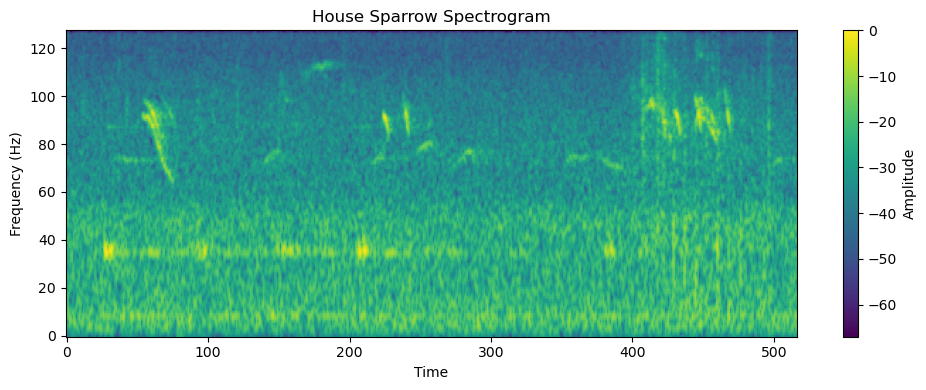

In [4]:
houspa = f['houspa']

plt.figure(figsize=(10, 4))
plt.imshow(houspa[:, :, 0], aspect='auto', origin='lower')
plt.colorbar(label='Amplitude')
plt.xlabel('Time')
plt.ylabel('Frequency (Hz)')
plt.title('House Sparrow Spectrogram')
plt.tight_layout()
plt.show()

## Binary Classification

Given that the species ``bewwre`` and ``spotow`` have similar class sizes, they will be used for the purposes of training a neural network to perform binary classification.

In [5]:
print(f['bewwre'].shape)
print(f['spotow'].shape)

(128, 517, 144)
(128, 517, 137)


Since the HDF5 file only possesses 3 dimensions (frequency, time, number of samples) and the convolutional neural network anticipates a 4D tensor, the two inputs for each species will have to be concatenated and transposed to conform to the model. By combining the two input arrays, a new 4-dimensional array is formed with the following attributes in order: number of samples, frequency, time, and number of channels). 

https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D

In [6]:
# create objects for each species' data
bewwre = f['bewwre']
spotow = f['spotow']

In [7]:
# rearrange dimensions so they follow batch_size, height, width (samples, frequency, time) order
bewwre = np.transpose(bewwre, (2, 0, 1))
spotow = np.transpose(spotow, (2, 0, 1))

print(bewwre.shape)
print(spotow.shape)

(144, 128, 517)
(137, 128, 517)


In [8]:
# add 4th dimension representing number of channels
bewwre = bewwre.reshape(bewwre.shape[0], bewwre.shape[1], bewwre.shape[2], 1)
spotow = spotow.reshape(spotow.shape[0], spotow.shape[1], spotow.shape[2], 1)

print(bewwre.shape)
print(spotow.shape)

(144, 128, 517, 1)
(137, 128, 517, 1)


With each species' data now formatted as a 4D tensor, the input and output variables can be formally defined as ``X`` and ``y`` respectively. ``X`` is defined by concatenating the two arrays together into a single array. By contrast, ``y`` is defined as a new array (1-dimensional vector) where the first 144 values for Bewick's Wren are labeled as 0's while the other 137 values for the Spotted Towhee are labeled as 1's.  From there, the input and output is split via an 80/20 train-test split.

The operations utilized were adapted from the following source:
https://stackoverflow.com/questions/71110042/how-to-label-arrays-with-labels-from-another-array

In [9]:
# define X and y
X = np.concatenate([bewwre, spotow], axis=0)
y = np.array([0]*len(bewwre) + [1]*len(spotow))

print(X.shape)   
print(y.shape)

(281, 128, 517, 1)
(281,)


In [10]:
X = X.astype('float32')
X = (X - (X.mean())) / (X.std())

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y
                                                    , test_size=0.2
                                                    , stratify=y
                                                    , random_state=1)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (224, 128, 517, 1)
Test shape: (57, 128, 517, 1)


A convolutional neural network with four total layers, two of convolution and two of pooling, is generated before being fit to the training data. This process was repeated three times with slight parameter adjustments in order to generate improvements in classification accuracy.

### Attempt #1

The first binary model was fit using a total of 30 epochs to see if and when accuracy and loss would reach their peak and determine if fewer epochs would provide an improvement. A batch size of 32 was arbitrarily selected to provide a reference point from which future models could be assessed.

In [12]:
model_bin1 = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=128, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.4),
    Dense(units=128, activation='relu'),
    Dense(units=1, activation='sigmoid')
])

model_bin1.summary()

C:\Users\jacob\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 129, 128)   │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 64, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    16,777,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,870,145 (64.35 MB)

 Trainable params: 16,870,145 (64.35 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
model_bin1.compile(loss='binary_crossentropy', 
                  optimizer='rmsprop', 
                  metrics=['accuracy'])

history_bin1 = model_bin1.fit(X_train, y_train, 
                            epochs=30,
                            batch_size=32,
                            validation_split=0.2)

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5363 - loss: 7.1940 - val_accuracy: 0.4222 - val_loss: 0.7045
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.5587 - loss: 0.6856 - val_accuracy: 0.4889 - val_loss: 0.7079
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.5642 - loss: 0.6904 - val_accuracy: 0.4222 - val_loss: 0.7115
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 854ms/step - accuracy: 0.5754 - loss: 0.6858 - val_accuracy: 0.4222 - val_loss: 0.7026
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 952ms/step - accuracy: 0.5587 - loss: 0.6935 - val_accuracy: 0.5111 - val_loss: 0.6955
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6145 - loss: 0.6588 - val_accuracy: 0.4444 - val_loss: 0.7825
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 850ms/step - accuracy: 0.6089 - loss: 0.6361 - val_accuracy: 0.5111 - val_loss: 0.9442
Epoch 8/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.6369 - loss: 0.6053 - val_accuracy: 0.5333 - val_loss: 0.7272
Epoch 9

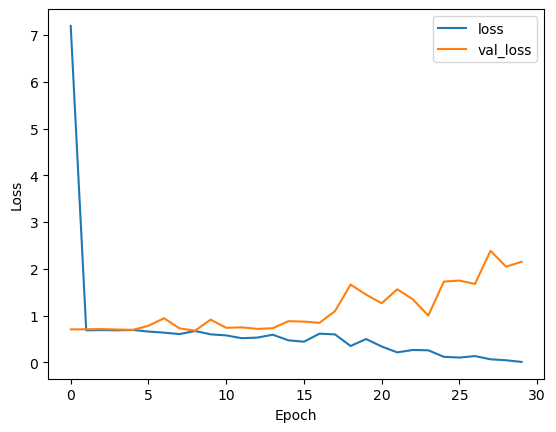

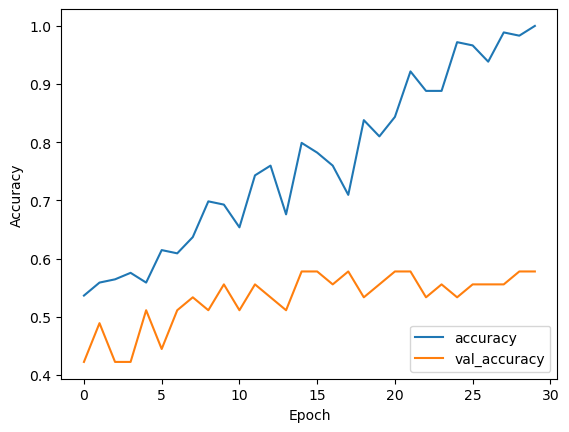

In [14]:
plt.plot(history_bin1.history['loss'])
plt.plot(history_bin1.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show();

plt.plot(history_bin1.history['accuracy'])
plt.plot(history_bin1.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['accuracy', 'val_accuracy'], loc='lower right')
plt.show();

In [15]:
score_bin1_train = model_bin1.evaluate(X_train, y_train, verbose=0)
print("Train Accuracy: {:.2f}%".format(score_bin1_train[1]*100))
print("Train Error: {:.2f}%".format((1-score_bin1_train[1])*100))

Train Accuracy: 91.52%
Train Error: 8.48%


In [16]:
score_bin1_test = model_bin1.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score_bin1_test[1]*100))
print("Test Error: {:.2f}%".format((1-score_bin1_test[1])*100))

Test Accuracy: 63.16%
Test Error: 36.84%


In [17]:
y_prob = model_bin1.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 440ms/step


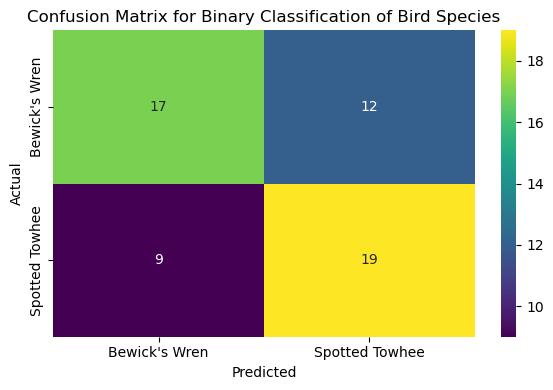

In [18]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm, annot=True, fmt='d', 
    xticklabels=["Bewick's Wren", "Spotted Towhee"], 
    yticklabels=["Bewick's Wren", "Spotted Towhee"], 
    cmap = 'viridis')

plt.title('Confusion Matrix for Binary Classification of Bird Species')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Attempt #2

In [19]:
model_bin2 = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=64, activation='relu'),
    Dense(units=1, activation='sigmoid')
    ])

C:\Users\jacob\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
model_bin2.compile(loss='binary_crossentropy', 
                  optimizer='rmsprop', 
                  metrics=['accuracy'])

history_bin2 = model_bin2.fit(X_train, y_train, 
                            epochs=15,
                            batch_size=16,
                            validation_split=0.2)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 441ms/step - accuracy: 0.4972 - loss: 4.7636 - val_accuracy: 0.5333 - val_loss: 0.7066
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 486ms/step - accuracy: 0.6034 - loss: 0.6841 - val_accuracy: 0.4222 - val_loss: 0.8435
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 484ms/step - accuracy: 0.5642 - loss: 0.6862 - val_accuracy: 0.5111 - val_loss: 0.7084
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 462ms/step - accuracy: 0.6927 - loss: 0.5803 - val_accuracy: 0.4222 - val_loss: 3.7450
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 346ms/step - accuracy: 0.6760 - loss: 0.8472 - val_accuracy: 0.5778 - val_loss: 0.7358
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 312ms/step - accuracy: 0.6983 - loss: 0.5971 - val_accuracy: 0.4889 - val_loss: 0.7010
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 487ms/step - accuracy: 0.7933 - loss: 0.4892 - val_accuracy: 0.4667 - val_loss: 0.7727
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 342ms/step - accuracy: 0.8324 - loss: 0.4204 - val_accuracy: 0.

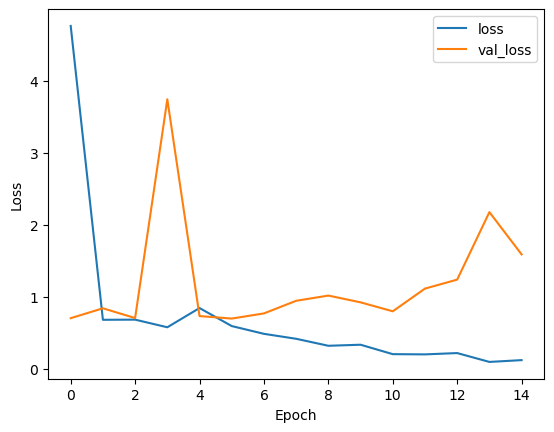

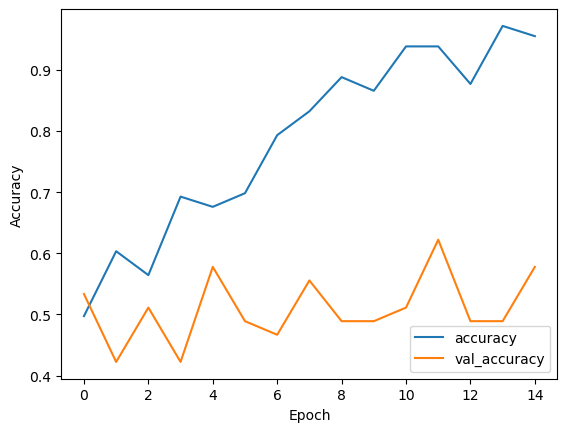

In [21]:
plt.plot(history_bin2.history['loss'])
plt.plot(history_bin2.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show();

plt.plot(history_bin2.history['accuracy'])
plt.plot(history_bin2.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['accuracy', 'val_accuracy'], loc='lower right')
plt.show();

In [22]:
score_bin2_train = model_bin2.evaluate(X_train, y_train, verbose=0)
print("Train Accuracy: {:.2f}%".format(score_bin2_train[1]*100))
print("Train Error: {:.2f}%".format((1-score_bin2_train[1])*100))

Train Accuracy: 90.18%
Train Error: 9.82%


In [23]:
score_bin2_test = model_bin2.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score_bin2_test[1]*100))
print("Test Error: {:.2f}%".format((1-score_bin2_test[1])*100))

Test Accuracy: 50.88%
Test Error: 49.12%


In [24]:
y_prob = model_bin2.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 298ms/step


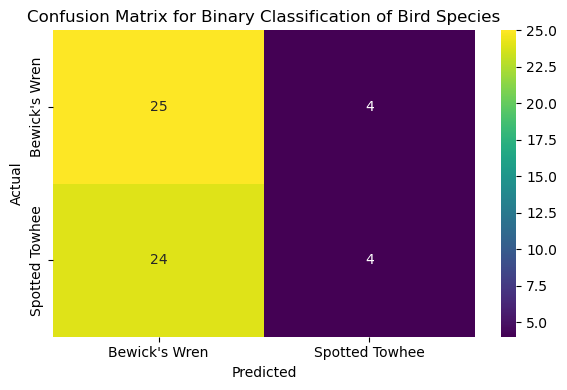

In [25]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm, annot=True, fmt='d', 
    xticklabels=["Bewick's Wren", "Spotted Towhee"], 
    yticklabels=["Bewick's Wren", "Spotted Towhee"], 
    cmap = 'viridis')

plt.title('Confusion Matrix for Binary Classification of Bird Species')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

### Attempt #3

The final binary model attempted utilized the same parameters as the previous model, though with a notable adjustment to the optimizer. Borrowing from the example linked below, an Adam optimizer was used in place of the RMSProp optimizer from before.

Source for incorporating Adam optimizer: https://keras.io/examples/audio/stft

In [27]:
model_bin3 = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128,517,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=64, activation='relu'),
    Dense(units=1, activation='sigmoid')
    ])

model_bin3.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │    16,908,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,927,233 (64.57 MB)

 Trainable params: 16,927,233 (64.57 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model_bin3.compile(loss='binary_crossentropy', 
                  optimizer='adam', 
                  metrics=['accuracy'])

history_bin3 = model_bin3.fit(X_train, y_train, 
                            epochs=15,
                            batch_size=16,
                            validation_split=0.2)

Epoch 1/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 406ms/step - accuracy: 0.4581 - loss: 2.9291 - val_accuracy: 0.5111 - val_loss: 0.9599
Epoch 2/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 418ms/step - accuracy: 0.5978 - loss: 0.7025 - val_accuracy: 0.5333 - val_loss: 0.6694
Epoch 3/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 472ms/step - accuracy: 0.6034 - loss: 0.6804 - val_accuracy: 0.5111 - val_loss: 0.6926
Epoch 4/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 364ms/step - accuracy: 0.6536 - loss: 0.6566 - val_accuracy: 0.4889 - val_loss: 0.6976
Epoch 5/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 347ms/step - accuracy: 0.7654 - loss: 0.5702 - val_accuracy: 0.4889 - val_loss: 0.8360
Epoch 6/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 318ms/step - accuracy: 0.7542 - loss: 0.5067 - val_accuracy: 0.5333 - val_loss: 0.7232
Epoch 7/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 346ms/step - accuracy: 0.8771 - loss: 0.4006 - val_accuracy: 0.5556 - val_loss: 0.9036
Epoch 8/15
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 356ms/step - accuracy: 0.8994 - loss: 0.3031 - val_accuracy: 0.

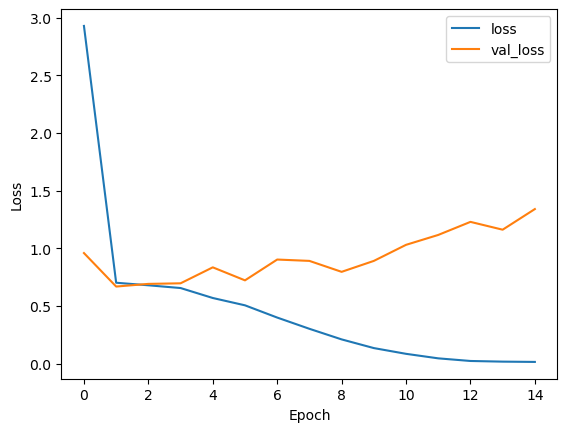

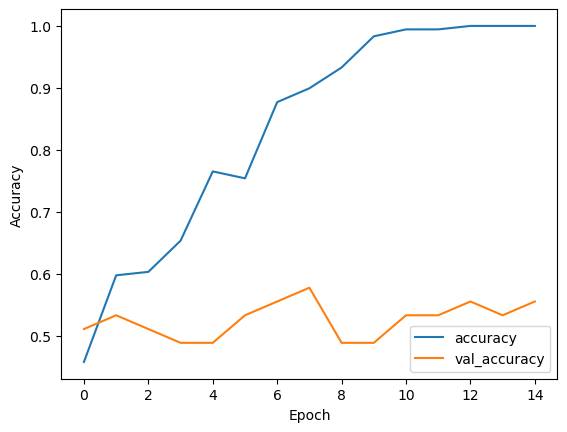

In [29]:
plt.plot(history_bin3.history['loss'])
plt.plot(history_bin3.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show();

plt.plot(history_bin3.history['accuracy'])
plt.plot(history_bin3.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['accuracy', 'val_accuracy'], loc='lower right')
plt.show();

In [30]:
score_bin3_train = model_bin3.evaluate(X_train, y_train, verbose=0)
print("Train Accuracy: {:.2f}%".format(score_bin3_train[1]*100))
print("Train Error: {:.2f}%".format((1-score_bin3_train[1])*100))

Train Accuracy: 91.07%
Train Error: 8.93%


In [31]:
score_bin3_test = model_bin3.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score_bin3_test[1]*100))
print("Test Error: {:.2f}%".format((1-score_bin3_test[1])*100))

Test Accuracy: 54.39%
Test Error: 45.61%


In [32]:
y_prob = model_bin3.predict(X_test)
y_pred = (y_prob > 0.5).astype(int)

1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 345ms/stepWARNING:tensorflow:6 out of the last 6 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x000001C4C246E3E0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step


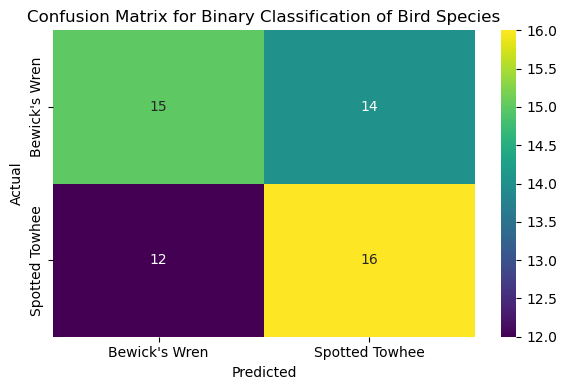

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm, annot=True, fmt='d', 
    xticklabels=["Bewick's Wren", "Spotted Towhee"], 
    yticklabels=["Bewick's Wren", "Spotted Towhee"], 
    cmap = 'viridis')

plt.title('Confusion Matrix for Binary Classification of Bird Species')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Multi-class Classification

For multi-class classification, the same preprocessing is utilized from binary classification, though now applied to all 12 species' data in order to generate 12 class labels from which we can identify.

In [34]:
# create objects for each species' data
amecro = f['amecro']
amerob = f['amerob']
bewwre = f['bewwre']
bkcchi = f['bkcchi']
daejun = f['daejun']
houfin = f['houfin']
houspa = f['houspa']
norfli = f['norfli']
rewbla = f['rewbla']
sonspa = f['sonspa']
spotow = f['spotow']
whcspa = f['whcspa']

In [35]:
# rearrange dimensions so they follow batch_size, height, width (samples, frequency, time) order
amecro = np.transpose(amecro, (2, 0, 1))
amerob = np.transpose(amerob, (2, 0, 1))
bewwre = np.transpose(bewwre, (2, 0, 1))
bkcchi = np.transpose(bkcchi, (2, 0, 1))
daejun = np.transpose(daejun, (2, 0, 1))
houfin = np.transpose(houfin, (2, 0, 1))
houspa = np.transpose(houspa, (2, 0, 1))
norfli = np.transpose(norfli, (2, 0, 1))
rewbla = np.transpose(rewbla, (2, 0, 1))
sonspa = np.transpose(sonspa, (2, 0, 1))
spotow = np.transpose(spotow, (2, 0, 1))
whcspa = np.transpose(whcspa, (2, 0, 1))

In [36]:
# add 4th dimension representing number of channels
amecro = amecro.reshape(amecro.shape[0], amecro.shape[1], amecro.shape[2], 1)
amerob = amerob.reshape(amerob.shape[0], amerob.shape[1], amerob.shape[2], 1)
bewwre = bewwre.reshape(bewwre.shape[0], bewwre.shape[1], bewwre.shape[2], 1)
bkcchi = bkcchi.reshape(bkcchi.shape[0], bkcchi.shape[1], bkcchi.shape[2], 1)
daejun = daejun.reshape(daejun.shape[0], daejun.shape[1], daejun.shape[2], 1)
houfin = houfin.reshape(houfin.shape[0], houfin.shape[1], houfin.shape[2], 1)
houspa = houspa.reshape(houspa.shape[0], houspa.shape[1], houspa.shape[2], 1)
norfli = norfli.reshape(norfli.shape[0], norfli.shape[1], norfli.shape[2], 1)
rewbla = rewbla.reshape(rewbla.shape[0], rewbla.shape[1], rewbla.shape[2], 1)
sonspa = sonspa.reshape(sonspa.shape[0], sonspa.shape[1], sonspa.shape[2], 1)
spotow = spotow.reshape(spotow.shape[0], spotow.shape[1], spotow.shape[2], 1)
whcspa = whcspa.reshape(whcspa.shape[0], whcspa.shape[1], whcspa.shape[2], 1)

In [37]:
# define X and y
X = np.concatenate([amecro, amerob, bewwre, bkcchi, daejun, houfin, houspa, norfli, rewbla, sonspa, spotow, whcspa], 
                   axis=0)
y = np.array([0]*len(amecro) + [1]*len(amerob) + [2]*len(bewwre) + [3]*len(bkcchi) + [4]*len(daejun)
            + [5]*len(houfin) + [6]*len(houspa) + [7]*len(norfli) + [8]*len(rewbla) + [9]*len(sonspa)
            + [10]*len(spotow) + [11]*len(whcspa))

print(X.shape)   
print(y.shape)

(1981, 128, 517, 1)
(1981,)


In [38]:
X = X.astype('float32')
X = (X - X.mean()) / (X.std())

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y
                                                    , test_size=0.2
                                                    , stratify=y
                                                    , random_state=1)

print('Train shape:', X_train.shape)
print('Test shape:', X_test.shape)

Train shape: (1584, 128, 517, 1)
Test shape: (397, 128, 517, 1)


### Attempt #1

The first multi-class model was fit using a total of 15 epochs and a batch size of 16, borrowing from the previous binary models. This would provide a baseline to be able to compare additional models.

In [40]:
model_mc1 = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=64, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

model_mc1.summary()

C:\Users\jacob\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │    16,908,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,927,948 (64.57 MB)

 Trainable params: 16,927,948 (64.57 MB)

 Non-trainable params: 0 (0.00 B)

In [41]:
model_mc1.compile(loss='sparse_categorical_crossentropy', 
                  optimizer='adam', 
                  metrics=['accuracy'])

history_mc1 = model_mc1.fit(X_train, y_train, 
                            epochs=15,
                            batch_size=16,
                            validation_split=0.2)

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 36s 422ms/step - accuracy: 0.2873 - loss: 3.1648 - val_accuracy: 0.3281 - val_loss: 2.2474
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 32s 403ms/step - accuracy: 0.3133 - loss: 2.1876 - val_accuracy: 0.3344 - val_loss: 2.1523
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 40s 504ms/step - accuracy: 0.3441 - loss: 2.0527 - val_accuracy: 0.3722 - val_loss: 2.0004
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 35s 440ms/step - accuracy: 0.4878 - loss: 1.6504 - val_accuracy: 0.3754 - val_loss: 1.8828
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 37s 465ms/step - accuracy: 0.6859 - loss: 1.0126 - val_accuracy: 0.4132 - val_loss: 1.8858
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 37s 468ms/step - accuracy: 0.8650 - loss: 0.4733 - val_accuracy: 0.4606 - val_loss: 2.3497
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 36s 448ms/step - accuracy: 0.9558 - loss: 0.1951 - val_accuracy: 0.4606 - val_loss: 2.4853
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 38s 473ms/step - accuracy: 0.9811 - loss: 0.0814 - val_accu

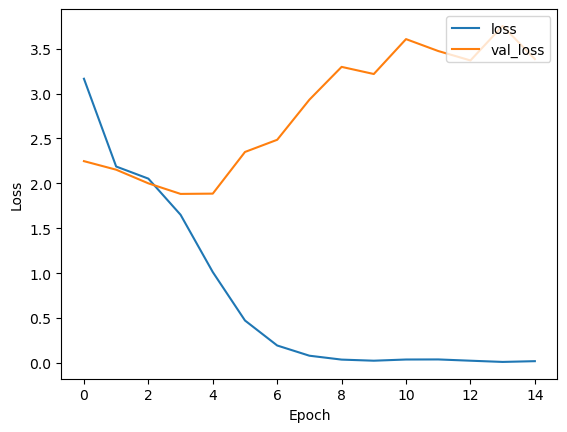

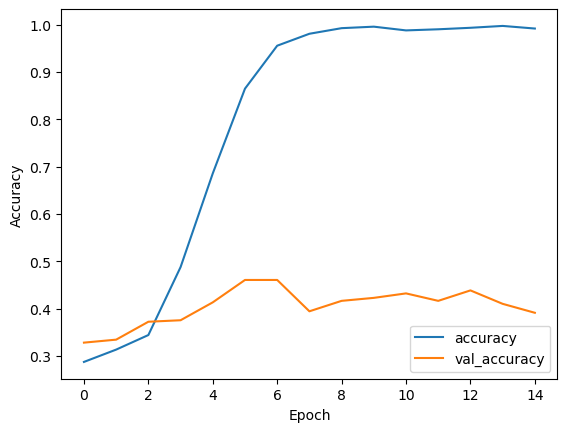

In [42]:
plt.plot(history_mc1.history['loss'])
plt.plot(history_mc1.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show();

plt.plot(history_mc1.history['accuracy'])
plt.plot(history_mc1.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['accuracy', 'val_accuracy'], loc='lower right')
plt.show();

In [43]:
score_mc1_train = model_mc1.evaluate(X_train, y_train, verbose=0)
print("Train Accuracy: {:.2f}%".format(score_mc1_train[1]*100))
print("Train Error: {:.2f}%".format((1-score_mc1_train[1])*100))

Train Accuracy: 87.50%
Train Error: 12.50%


In [44]:
score_mc1_test = model_mc1.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score_mc1_test[1]*100))
print("Test Error: {:.2f}%".format((1-score_mc1_test[1])*100))

Test Accuracy: 42.82%
Test Error: 57.18%


In [45]:
y_prob = model_mc1.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 191ms/step


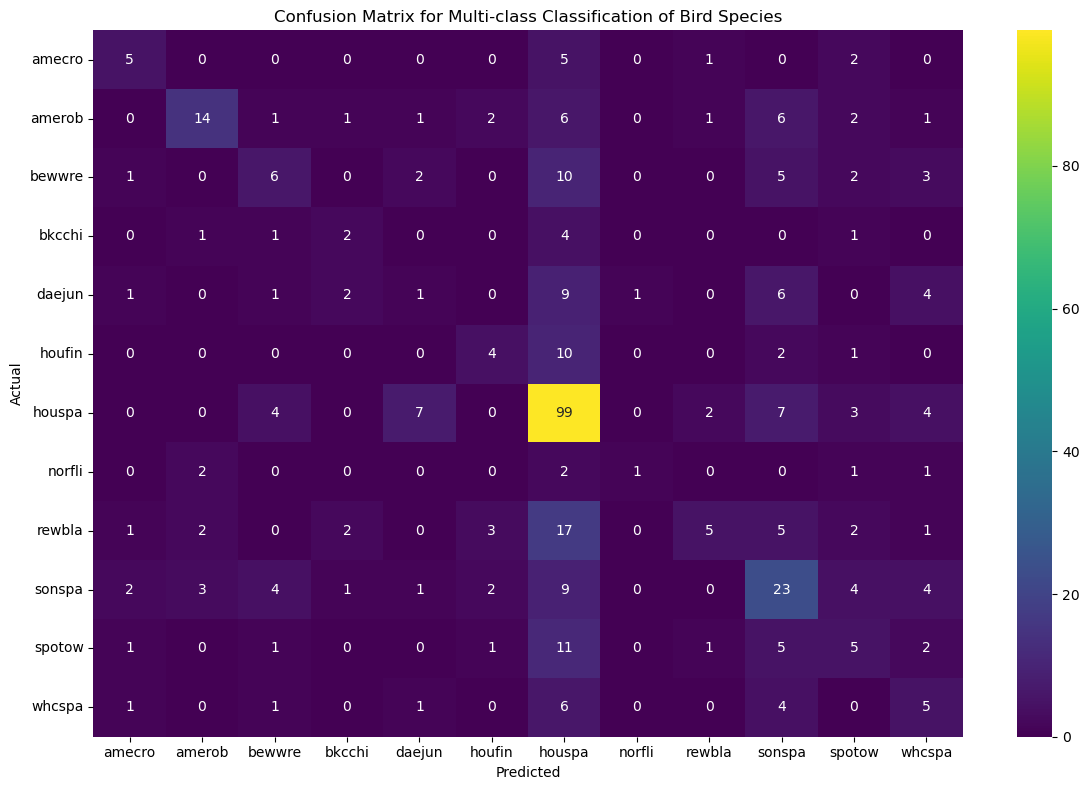

In [46]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm, annot=True, fmt='d', 
    xticklabels=['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 
                 'sonspa', 'spotow', 'whcspa'], 
    yticklabels=['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 
                 'sonspa', 'spotow', 'whcspa'], 
    cmap = 'viridis')

plt.title('Confusion Matrix for Multi-class Classification of Bird Species')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [47]:
print((np.unique_counts(y_test)))

UniqueCountsResult(values=array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11]), counts=array([ 13,  35,  29,   9,  25,  17, 126,   7,  38,  53,  27,  18]))


### Attempt #2

The following model possesses the same underlying structure as the previous multi-classification model, though with an even smaller batch size of 8. 

In [48]:
model_mc2 = Sequential(
    [
    Conv2D(filters=32, kernel_size=(3,3), padding='same', activation='relu', input_shape=(128, 517, 1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), padding='same', activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dropout(rate=0.5),
    Dense(units=64, activation='relu'),
    Dense(units=12, activation='softmax')
    ])

model_mc2.summary()

C:\Users\jacob\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 128, 517, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 64, 258, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 258, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 32, 129, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 264192)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │    16,908,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,927,948 (64.57 MB)

 Trainable params: 16,927,948 (64.57 MB)

 Non-trainable params: 0 (0.00 B)

In [49]:
model_mc2.compile(loss='sparse_categorical_crossentropy', 
                  optimizer='adam', 
                  metrics=['accuracy'])

history_mc2 = model_mc2.fit(X_train, y_train, 
                            epochs=15,
                            batch_size=8,
                            validation_split=0.2)

Epoch 1/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 49s 301ms/step - accuracy: 0.2889 - loss: 2.4511 - val_accuracy: 0.3312 - val_loss: 2.1613
Epoch 2/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 45s 280ms/step - accuracy: 0.3220 - loss: 2.1217 - val_accuracy: 0.3438 - val_loss: 2.0587
Epoch 3/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 45s 281ms/step - accuracy: 0.4025 - loss: 1.8661 - val_accuracy: 0.3375 - val_loss: 2.0801
Epoch 4/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 45s 281ms/step - accuracy: 0.5699 - loss: 1.3786 - val_accuracy: 0.3975 - val_loss: 1.9604
Epoch 5/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 47s 294ms/step - accuracy: 0.7782 - loss: 0.7112 - val_accuracy: 0.3754 - val_loss: 2.3931
Epoch 6/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 43s 271ms/step - accuracy: 0.9013 - loss: 0.3440 - val_accuracy: 0.4101 - val_loss: 2.6873
Epoch 7/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 43s 268ms/step - accuracy: 0.9471 - loss: 0.1723 - val_accuracy: 0.3817 - val_loss: 3.8050
Epoch 8/15
159/159 ━━━━━━━━━━━━━━━━━━━━ 42s 263ms/step - accuracy: 0.9605 - loss: 0

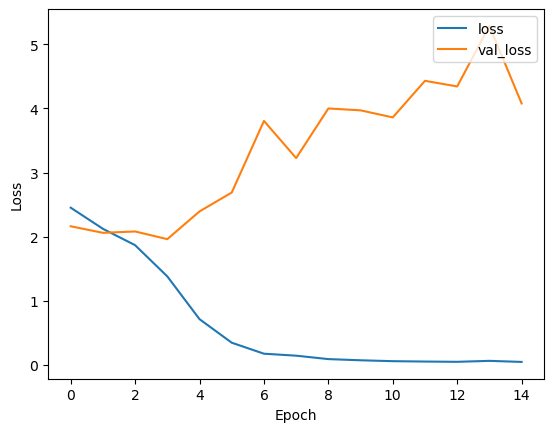

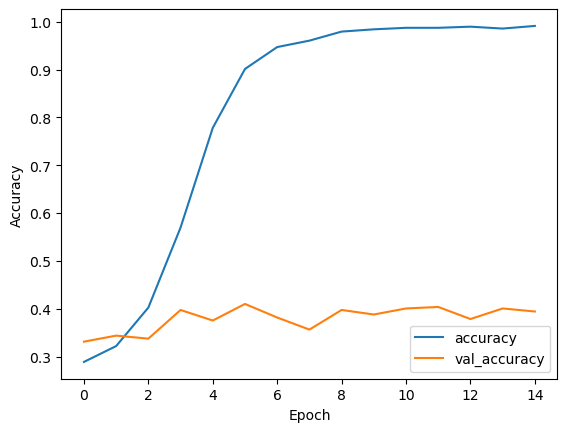

In [50]:
plt.plot(history_mc2.history['loss'])
plt.plot(history_mc2.history['val_loss'])
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['loss', 'val_loss'], loc='upper right')
plt.show();

plt.plot(history_mc2.history['accuracy'])
plt.plot(history_mc2.history['val_accuracy'])
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['accuracy', 'val_accuracy'], loc='lower right')
plt.show();

In [51]:
score_mc2_train = model_mc2.evaluate(X_train, y_train, verbose=0)
print("Train Accuracy: {:.2f}%".format(score_mc2_train[1]*100))
print("Train Error: {:.2f}%".format((1-score_mc2_train[1])*100))

Train Accuracy: 87.75%
Train Error: 12.25%


In [52]:
score_mc2_test = model_mc2.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy: {:.2f}%".format(score_mc2_test[1]*100))
print("Test Error: {:.2f}%".format((1-score_mc2_test[1])*100))

Test Accuracy: 45.34%
Test Error: 54.66%


In [53]:
y_prob = model_mc2.predict(X_test)
y_pred = np.argmax(y_prob, axis=1)

13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step


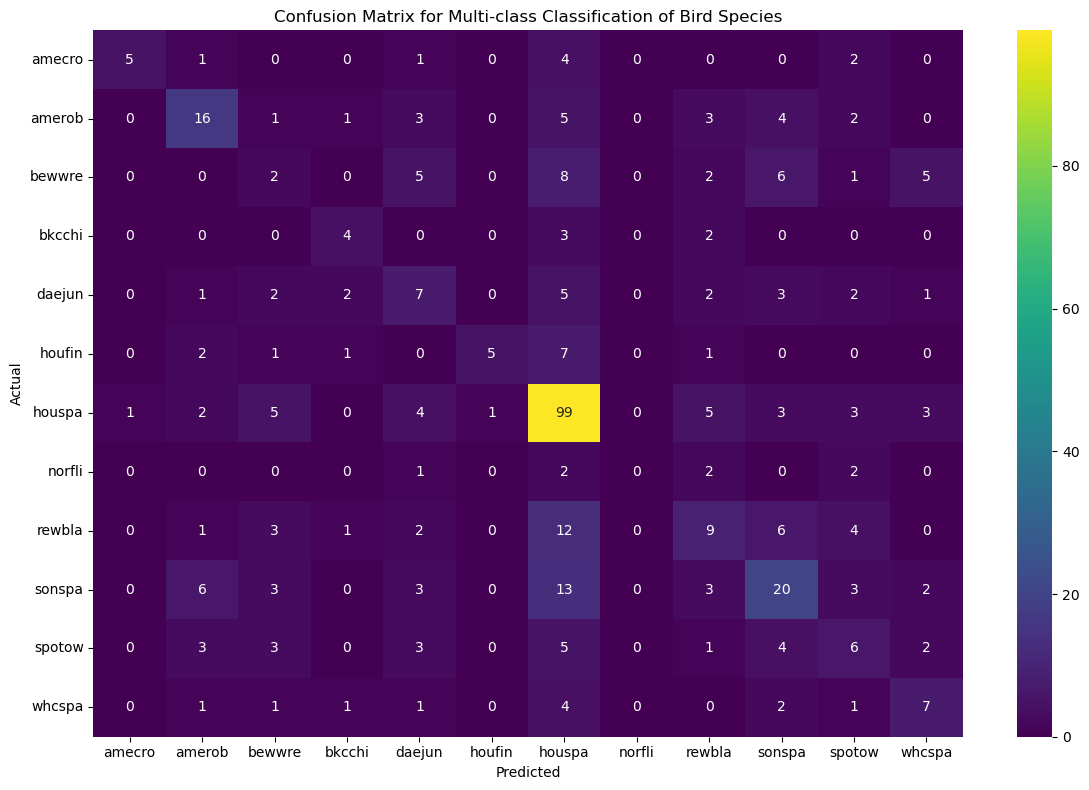

In [54]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 8))

sns.heatmap(
    cm, annot=True, fmt='d', 
    xticklabels=['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 
                 'sonspa', 'spotow', 'whcspa'], 
    yticklabels=['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 
                 'sonspa', 'spotow', 'whcspa'], 
    cmap = 'viridis')

plt.title('Confusion Matrix for Multi-class Classification of Bird Species')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

## Testing with External Test Data

Using the ``librosa`` package from Python, each of the three test audio clips are loaded into the environment as a NumPy array. Each clip has its sample rate adjusted to 22050 Hz and is clipped to 3 seconds in order to align with the preprocessing done on the existing bird call data. 

For each audio clip, a visualization of its waveform is displayed using the ``waveshow`` function. These visualizations capture the changes in amplitude over time. 

The code used below was adapted from the following links: \
https://www.kaggle.com/code/msripooja/steps-to-convert-audio-clip-to-spectrogram \
https://librosa.org/doc/main/generated/librosa.display.waveshow.html

In [70]:
audio_path = 'C:/Users/jacob/Downloads/'

# load the three audio clips with adjusted sampling rate and duration
x, sr = librosa.load(audio_path + 'test1.mp3', sr=22050) 
x = x[:sr*3]

x2, sr = librosa.load(audio_path + 'test2.mp3', sr=22050)
x2 = x2[:sr*3]

x3, sr = librosa.load(audio_path + 'test3.mp3', sr=22050)
x3 = x3[:sr*3]

print(type(x), type(sr))
print(type(x2), type(sr))
print(type(x3), type(sr))
print(x.shape, sr)
print(x2.shape, sr)
print(x3.shape, sr)

<class 'numpy.ndarray'> <class 'int'>
<class 'numpy.ndarray'> <class 'int'>
<class 'numpy.ndarray'> <class 'int'>
(66150,) 22050
(66150,) 22050
(66150,) 22050


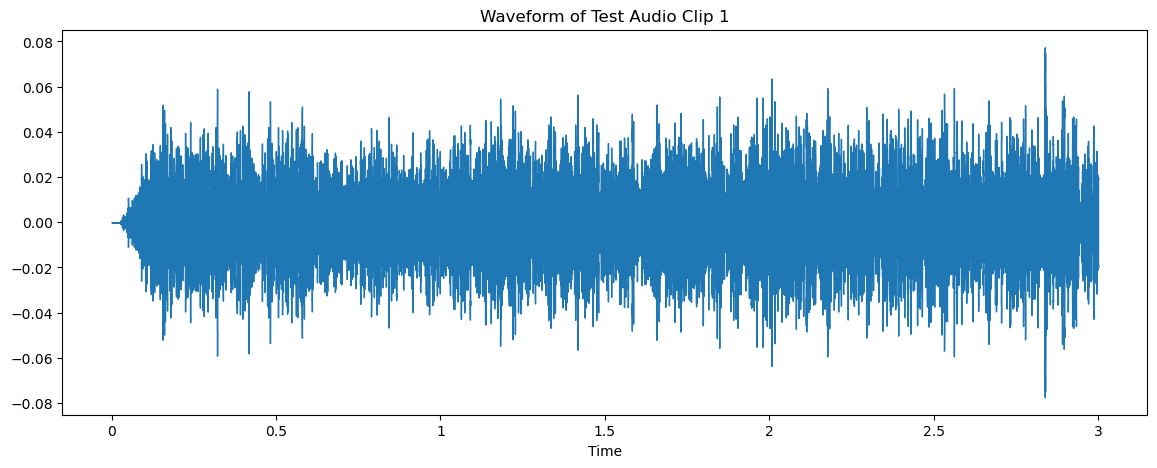

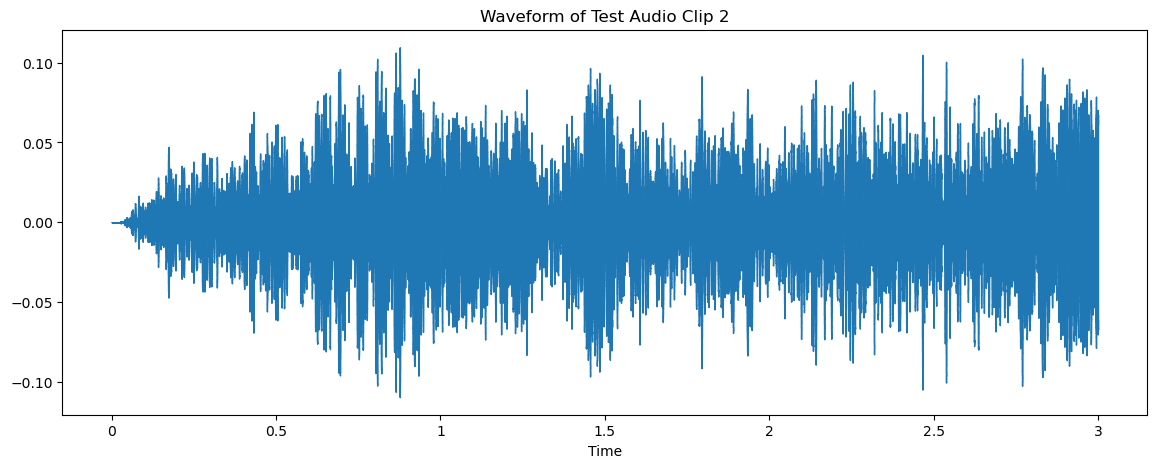

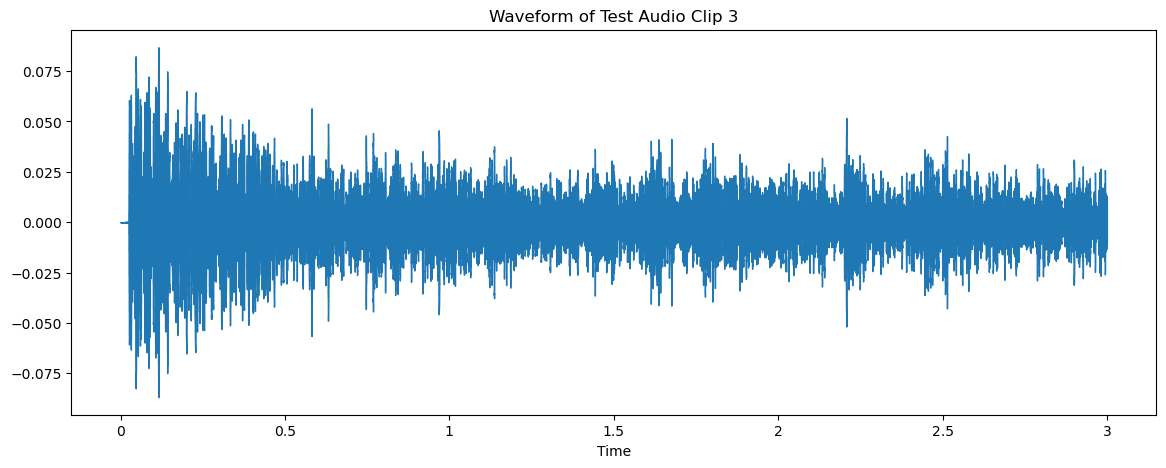

In [71]:
plt.figure(figsize=(14, 5))
plt.title('Waveform of Test Audio Clip 1')
librosa.display.waveshow(x, sr=sr)
plt.figure(figsize=(14, 5))
plt.title('Waveform of Test Audio Clip 2')
librosa.display.waveshow(x2, sr=sr)
plt.figure(figsize=(14, 5))
plt.title('Waveform of Test Audio Clip 3')
librosa.display.waveshow(x3, sr=sr)

In order for the audio clip to be interpreted by the multi-class classification model, it will first be converted into a spectrogram with shape (128, 517) in order to align with the size of the spectrograms from the preprocessed data. Using the link below for reference, each audio clip's array is converted into a spectrogram with adjustments made to the ``hop_length`` parameter to ensure the desired shape, before being visualized using the ``specshow`` function.

The incorporation of this function followed code from the following source: https://librosa.org/doc/main/generated/librosa.feature.melspectrogram.html

In [72]:
x_spec = librosa.feature.melspectrogram(y=x, sr=sr, n_mels=128, hop_length=128)
x_spec_db = librosa.power_to_db(x_spec, ref=np.max)

x_spec2 = librosa.feature.melspectrogram(y=x2, sr=sr, n_mels=128, hop_length=128)
x_spec_db2 = librosa.power_to_db(x_spec2, ref=np.max)

x_spec3 = librosa.feature.melspectrogram(y=x3, sr=sr, n_mels=128, hop_length=128)
x_spec_db3 = librosa.power_to_db(x_spec3, ref=np.max)

print(x_spec_db.shape)
print(x_spec_db2.shape)
print(x_spec_db3.shape)

(128, 517)
(128, 517)
(128, 517)


Text(0.5, 1.0, 'Audio Clip 3 Spectrogram')

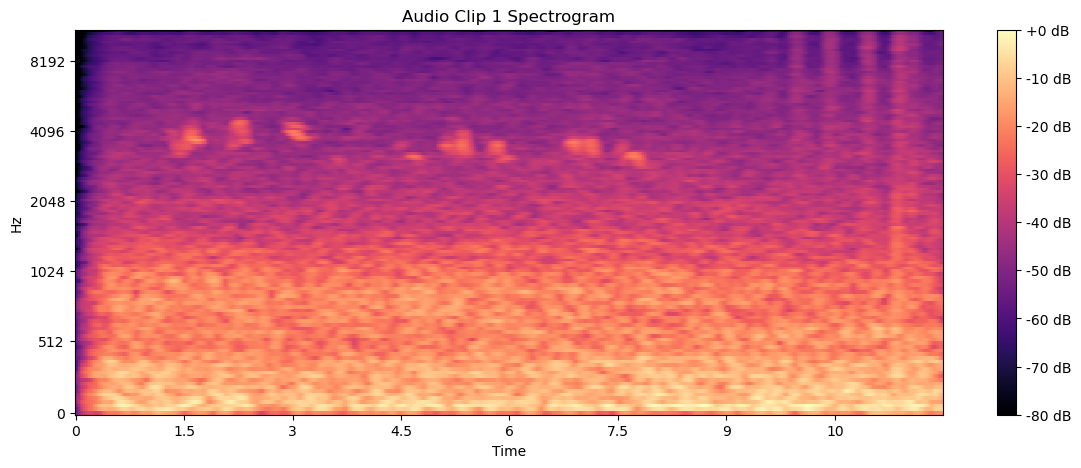

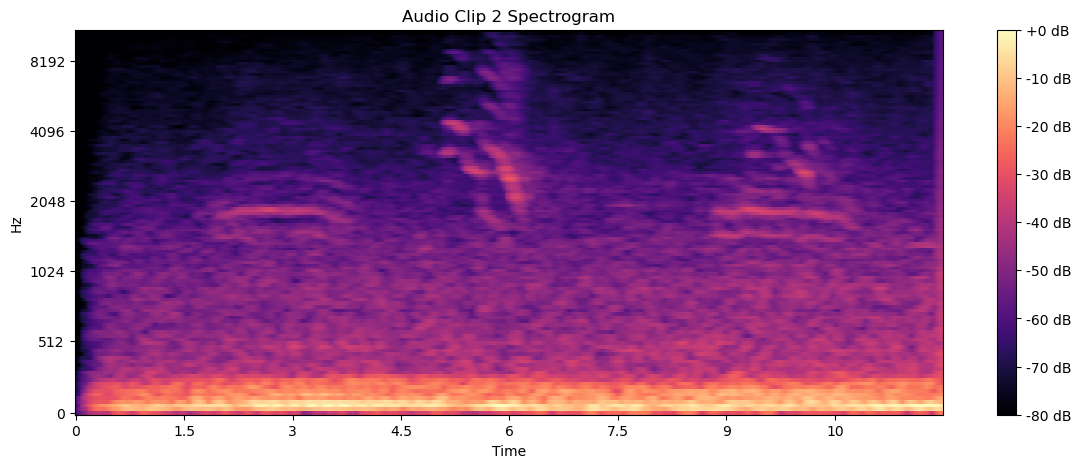

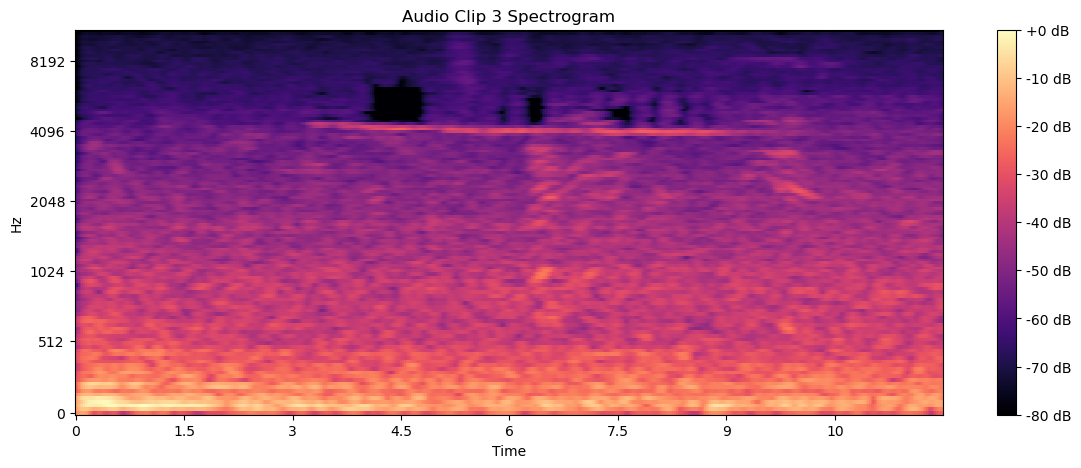

In [73]:
plt.figure(figsize=(14, 5))
librosa.display.specshow(x_spec_db, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Audio Clip 1 Spectrogram')

plt.figure(figsize=(14, 5))
librosa.display.specshow(x_spec_db2, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Audio Clip 2 Spectrogram')

plt.figure(figsize=(14, 5))
librosa.display.specshow(x_spec_db3, x_axis='time', y_axis='mel', sr=sr)
plt.colorbar(format='%+2.0f dB')
plt.title('Audio Clip 3 Spectrogram')

In accordance with the binary and multi-class classification processes, each spectrogram will be reshaped into a 4D tensor that can be interpreted by the final multi-class classification model. 

In [74]:
x_spec_db = x_spec_db.reshape(1, x_spec_db.shape[0], x_spec_db.shape[1], 1)
x_spec_db2 = x_spec_db2.reshape(1, x_spec_db2.shape[0], x_spec_db2.shape[1], 1)
x_spec_db3 = x_spec_db3.reshape(1, x_spec_db3.shape[0], x_spec_db3.shape[1], 1)
print(x_spec_db.shape, x_spec_db2.shape, x_spec_db3.shape)

(1, 128, 517, 1) (1, 128, 517, 1) (1, 128, 517, 1)


In [75]:
x_spec_db = (x_spec_db - (X.mean())) / (X.std())
x_spec_db2 = (x_spec_db2 - (X.mean())) / (X.std())
x_spec_db3 = (x_spec_db3 - (X.mean())) / (X.std())

Lastly, the both multi-class models are used to predict on the new spectrograms and output probabilities for each of the 12 classes. 

In [76]:
pred1 = model_mc1.predict(x_spec_db)
pred2 = model_mc1.predict(x_spec_db2)
pred3 = model_mc1.predict(x_spec_db3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


In [77]:
species = ['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 
          'sonspa', 'spotow', 'whcspa']

print(species[np.argmax(pred1, axis=1)[0]])
print(species[np.argmax(pred2, axis=1)[0]])
print(species[np.argmax(pred3, axis=1)[0]])

houspa
rewbla
rewbla


In [78]:
for s, prob in sorted(zip(species, pred1[0]), key=lambda x: -x[1]):
        print(f'{s}: {prob:.4f}')

houspa: 0.6549
rewbla: 0.3451
amerob: 0.0000
whcspa: 0.0000
spotow: 0.0000
sonspa: 0.0000
daejun: 0.0000
norfli: 0.0000
amecro: 0.0000
bewwre: 0.0000
bkcchi: 0.0000
houfin: 0.0000


In [79]:
for s, prob in sorted(zip(species, pred2[0]), key=lambda x: -x[1]):
        print(f'{s}: {prob:.4f}')

rewbla: 1.0000
houspa: 0.0000
whcspa: 0.0000
amerob: 0.0000
amecro: 0.0000
bewwre: 0.0000
bkcchi: 0.0000
daejun: 0.0000
houfin: 0.0000
norfli: 0.0000
sonspa: 0.0000
spotow: 0.0000


In [80]:
for s, prob in sorted(zip(species, pred3[0]), key=lambda x: -x[1]):
        print(f'{s}: {prob:.4f}')

rewbla: 1.0000
houspa: 0.0000
amerob: 0.0000
whcspa: 0.0000
amecro: 0.0000
bewwre: 0.0000
bkcchi: 0.0000
daejun: 0.0000
houfin: 0.0000
norfli: 0.0000
sonspa: 0.0000
spotow: 0.0000


In [81]:
pred1b = model_mc2.predict(x_spec_db)
pred2b = model_mc2.predict(x_spec_db2)
pred3b = model_mc2.predict(x_spec_db3)

species = ['amecro', 'amerob', 'bewwre', 'bkcchi', 'daejun', 'houfin', 'houspa', 'norfli', 'rewbla', 
          'sonspa', 'spotow', 'whcspa']

print(species[np.argmax(pred1b, axis=1)[0]])
print(species[np.argmax(pred2b, axis=1)[0]])
print(species[np.argmax(pred3b, axis=1)[0]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
houspa
houspa
houspa


In [82]:
for s, prob in sorted(zip(species, pred1b[0]), key=lambda x: -x[1]):
        print(f'{s}: {prob:.4f}') 

houspa: 1.0000
amecro: 0.0000
amerob: 0.0000
bewwre: 0.0000
bkcchi: 0.0000
daejun: 0.0000
houfin: 0.0000
norfli: 0.0000
rewbla: 0.0000
sonspa: 0.0000
spotow: 0.0000
whcspa: 0.0000


In [83]:
for s, prob in sorted(zip(species, pred2b[0]), key=lambda x: -x[1]):
        print(f'{s}: {prob:.4f}')

houspa: 1.0000
amecro: 0.0000
amerob: 0.0000
bewwre: 0.0000
bkcchi: 0.0000
daejun: 0.0000
houfin: 0.0000
norfli: 0.0000
rewbla: 0.0000
sonspa: 0.0000
spotow: 0.0000
whcspa: 0.0000


In [84]:
for s, prob in sorted(zip(species, pred3b[0]), key=lambda x: -x[1]):
        print(f'{s}: {prob:.4f}')

houspa: 1.0000
amecro: 0.0000
amerob: 0.0000
bewwre: 0.0000
bkcchi: 0.0000
daejun: 0.0000
houfin: 0.0000
norfli: 0.0000
rewbla: 0.0000
sonspa: 0.0000
spotow: 0.0000
whcspa: 0.0000


## Model Comparisons

**Binary Classification Models:**

| Model | Training Accuracy | Training Error Rate | Test Accuracy | Test Error Rate | Key Parameters
|---|---|---|---|---|---|
| Model 1 | 91.52% | 8.48% | 63.16% | 36.84% | dropout rate = 0.4, epochs = 30, batch size = 32 |
| Model 2 | 90.18% | 9.82% | 50.88% | 49.12% | dropout rate = 0.5, epochs = 15, batch size = 16 |
| Model 3 | 91.07% | 8.93% | 54.39% | 45.61% | dropout rate = 0.5, epochs = 15, batch size = 16 |

**Multi-class Classification Models:**

| Model | Training Accuracy | Training Error Rate | Test Accuracy | Test Error Rate | Key Parameters
|---|---|---|---|---|---|
| Model 1 | 87.50% | 12.50% | 42.82% | 57.18% | dropout rate = 0.5, epochs = 15, batch size = 16 |
| Model 2 | 87.75% | 12.25% | 45.34% | 54.66% | dropout rate = 0.5, epochs = 15, batch size = 8 |

**Audio Clip Identification Results:**

| Clip | Model 1 Prediction | Model 2 Prediction |
|---|---|---|
| Audio Clip 1 | House Sparrow | House Sparrow |
| Audio Clip 2 | Red-winged Blackbird | House Sparrow |
| Audio Clip 3 | Red-winged Blackbird | House Sparrow | 